In [16]:
import sys

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')


In [72]:
import torch
from src.language_models.dictionary_corpus import Dictionary
from src.language_models.model import CBR_RNN
from evaluation_notebooks.utils import NounPPDataset, collate_fn
from torch.utils.data import DataLoader
from collections import defaultdict
from wm_tests.utils import CBR_RNN_attn_tracking, WMTestDataset, collate_fn, eval, plot_attention
import numpy as np
import pandas as pd

In [18]:
device = torch.device('cpu')

In [19]:
model = CBR_RNN_attn_tracking(50001, 128, 128, 1, 0, device)
# check = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_128/epoch_1.pt', map_location = 'cpu')
# model.load_state_dict(check['model_state_dict'])

In [20]:
sentence_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat.txt'
marker_path = '/scratch2/mrenaudin/colorlessgreenRNNs/wm_tests/rnn_input_files/categorized_lists_sce3_repeat_markers.txt'
data_path = "/scratch2/mrenaudin/colorlessgreenRNNs/english_data"
dictionary = Dictionary(data_path)
wm_dataset = WMTestDataset(sentence_path, marker_path, dictionary)

In [42]:

test_dataloader = DataLoader(wm_dataset, batch_size=230, collate_fn=collate_fn)

In [43]:
surprisal, attention, encoded_sentence = eval(model, test_dataloader, nheads=1, temperature=1, gs=False)

# How many tokens attended for different gumbel softmax temperature ? 

In [88]:
gs = [1, 0.75, 0.5, 0.25, 0.1, 0.075, 0.05, 0.025, 0.01]
results=[]
for t in gs : 
    surprisal, attention, encoded_sentence = eval(model, test_dataloader, nheads=1, temperature=t, gs=True)
    attn = attention[-1].squeeze()
    len_sentence = attn.shape[1]
    max_diff = []
    sharpness = []
    #argmax_diff=[]
    for j in range(attn.shape[0]):
        differences = []
        for i in range(1, len_sentence):
            differences.append(attn[j, i-1] - attn[j,i])

        max_diff_p = np.max(differences)
        max_diff.append(max_diff_p)
        #argmax_diff_p = np.argmax(differences)
        #argmax_diff.append(argmax_diff_p)
        vec = attn[j].detach().cpu().numpy()  # 1D attention vector, shape (seq_len,)
        max_val = np.max(vec)
        min_val = np.min(vec)
        closer_to_max = np.sum(np.abs(vec - max_val) < np.abs(vec - min_val))
        sharpness.append(closer_to_max)  
        
    results.append({
        "gs": t,
        "mean_max_diff": np.median(max_diff),
        "mean_sharpness": np.mean(sharpness)
    })
df = pd.DataFrame(results)

In [89]:
df

,gs,mean_max_diff,mean_sharpness
0,1.000,0.029074,4.869565
1,0.750,0.045685,5.639130
2,0.500,0.064318,2.356522
3,0.250,0.237947,2.886957
4,0.100,0.414581,1.878261
5,0.075,0.724161,1.273913
6,0.050,0.865586,1.165217
7,0.025,0.986638,1.104348
8,0.010,0.998758,1.060870


# Plot attention

In [44]:
att_matrix = torch.zeros((len(attention), len(attention)))  # 50 x 50

for t in range(len(attention)):
    att_t = attention[t].squeeze()  # shape: (t+1,)
    att_matrix[t, :t+1] = att_t
    print(att_t)

tensor(1.)
tensor([0.7659, 0.2341])
tensor([0.7163, 0.1723, 0.1114])
tensor([0.5365, 0.2376, 0.0823, 0.1437])
tensor([0.5032, 0.1489, 0.0713, 0.1273, 0.1493])
tensor([0.4243, 0.1289, 0.0642, 0.0665, 0.1525, 0.1637])
tensor([0.2862, 0.0895, 0.0366, 0.0540, 0.0744, 0.0880, 0.3713])
tensor([0.2593, 0.0635, 0.0250, 0.0906, 0.0429, 0.1105, 0.3002, 0.1079])
tensor([0.2923, 0.0548, 0.0298, 0.0759, 0.0431, 0.0826, 0.2544, 0.1048, 0.0624])
tensor([0.2101, 0.0928, 0.0278, 0.0442, 0.0611, 0.0731, 0.2955, 0.0770, 0.0425,
        0.0759])
tensor([0.1886, 0.0588, 0.0221, 0.0664, 0.0375, 0.0926, 0.1889, 0.0692, 0.0430,
        0.0687, 0.1643])
tensor([0.1817, 0.0744, 0.0260, 0.0321, 0.0531, 0.0504, 0.2269, 0.0684, 0.0390,
        0.0609, 0.1381, 0.0489])
tensor([0.1498, 0.0812, 0.0287, 0.0217, 0.0566, 0.0509, 0.1963, 0.0534, 0.0333,
        0.0457, 0.0904, 0.0421, 0.1501])
tensor([0.1413, 0.0523, 0.0226, 0.0401, 0.0396, 0.0576, 0.1456, 0.0522, 0.0328,
        0.0535, 0.1013, 0.0380, 0.1388, 0.0842])


In [45]:
encoded_sentence = encoded_sentence.squeeze(0)
sentence = [
    dictionary.idx2word[int(word)] if int(word) < len(dictionary.idx2word) else "<unk>"
    for word in encoded_sentence
]


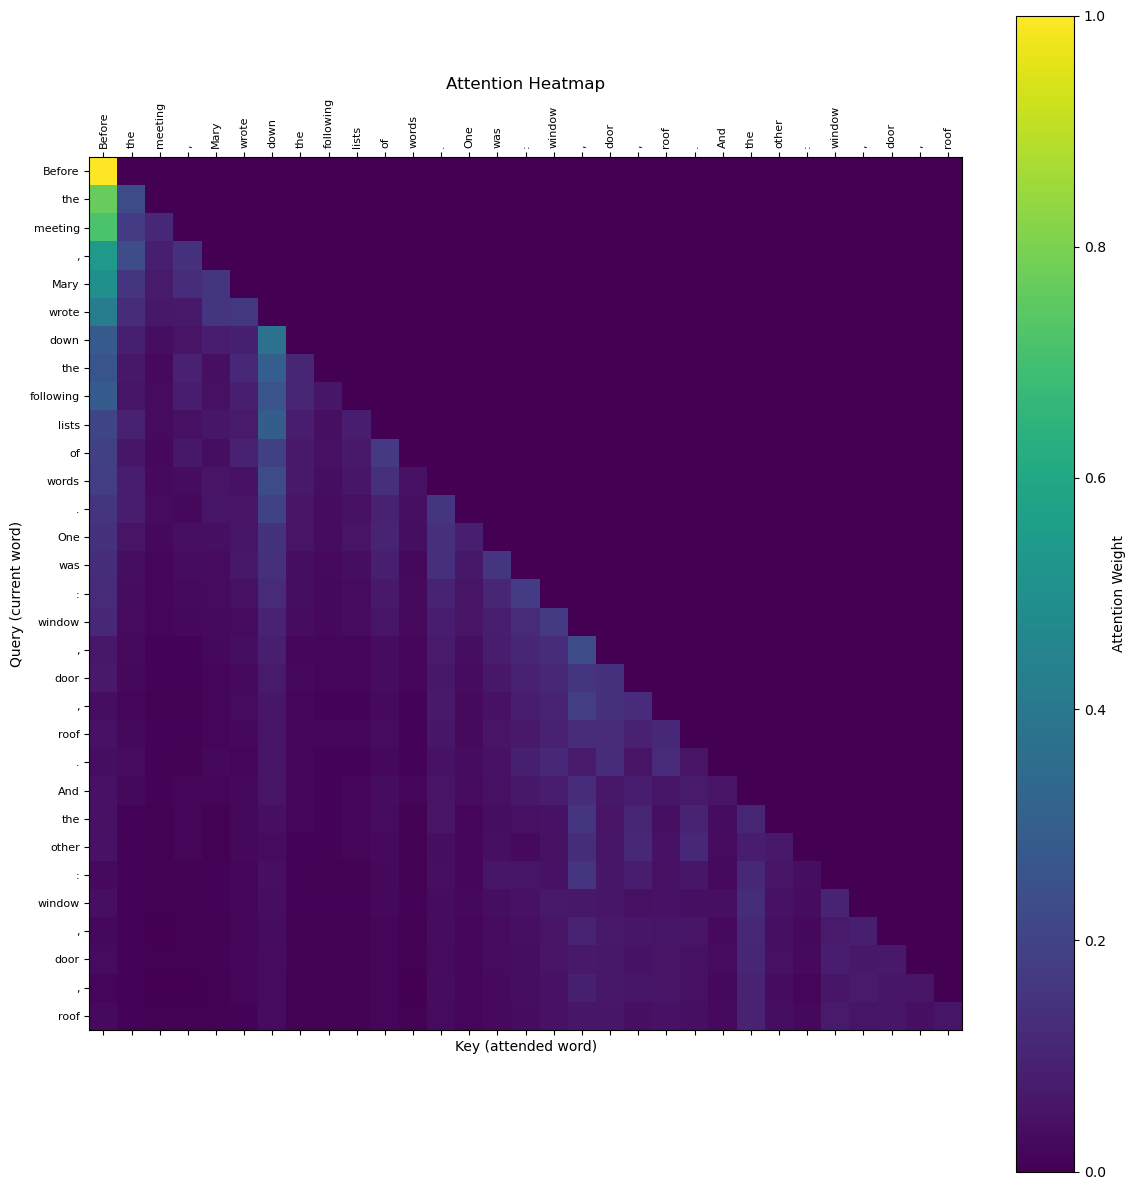

In [46]:
plot_attention(att_matrix, sentence)